# 02 - Preprocessing & Feature Engineering

## 2.1 - Caricamento Dati

In [73]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Carica i dataset puliti dal notebook precedente
df_anagrafica_clean = pd.read_csv('./data/df_anagrafica_clean.csv')
df_storico_clean = pd.read_csv('./data/df_storico_clean.csv')
df_macro = pd.read_csv('./data/df_macro.csv', index_col=0, parse_dates=True)

# Assicurati che le date siano datetime
df_storico_clean['referencedate'] = pd.to_datetime(df_storico_clean['referencedate'])
df_anagrafica_clean['redemptiondate'] = pd.to_datetime(df_anagrafica_clean['redemptiondate'], format='%d/%m/%Y', errors='coerce')

print(f"✓ Dataset caricati")
print(f"  Anagrafica: {df_anagrafica_clean.shape}")
print(f"  Storico: {df_storico_clean.shape}")
print(f"  Macro: {df_macro.shape}")

✓ Dataset caricati
  Anagrafica: (473, 10)
  Storico: (320287, 8)
  Macro: (9625, 10)


## 2.2 - Controllo qualità dei dati

In [74]:
# 1. Duplicati su ISIN+Data
if 'isincode' in df_storico_clean.columns and 'referencedate' in df_storico_clean.columns:
    n_dupes = df_storico_clean.duplicated(subset=['isincode', 'referencedate']).sum()
    print(f"Duplicati su ISIN+Data nello storico: {n_dupes}")
    
# 2. Missing nelle colonne chiave
print("\nMissing values nelle colonne chiave:")
print(df_storico_clean[['isincode', 'referencedate', 'pricevalue']].isnull().sum())
print("\nAnag missing:")
print(df_anagrafica_clean[['isincode', 'redemptiondate', 'description']].isnull().sum())

Duplicati su ISIN+Data nello storico: 0

Missing values nelle colonne chiave:
isincode         0
referencedate    0
pricevalue       0
dtype: int64

Anag missing:
isincode          0
redemptiondate    0
description       0
dtype: int64


## 2.3 - Feature Extraction: Coupon (Text Mining)

Il tasso cedolare (*Coupon Rate*) è una variabile fondamentale per il pricing di un'obbligazione, in quanto determina i flussi di cassa periodici e permette il calcolo accurato del rendimento a scadenza. Poiché il dataset originale non fornisce questo dato, è stato necessario implementare un processo di *Text Mining* sulla colonna testuale `description`.

L'algoritmo di estrazione si basa su due logiche complementari:
1. **Espressioni Regolari (Regex):** Vengono utilizzati pattern dinamici per intercettare i valori percentuali (es. "3.15%") o i valori assoluti associati alla valuta (es. "EUR 5") all'interno della stringa descrittiva, standardizzando i separatori decimali.
2. **Gestione dei Titoli Zero-Coupon:** I titoli a breve termine (come i BOT o i CTZ) non staccano cedole periodiche, ma garantiscono il rendimento tramite lo scarto di emissione. L'algoritmo intercetta specifiche keyword (es. *'bot'*, *'zc'*, *'zero'*) assegnando matematicamente un coupon pari a `0.0`.

Qualora la funzione restituisca `NaN` (informazione non estraibile), il titolo viene scartato.

In [75]:
def extract_coupon(description):
    """
    Estrae il tasso di cedola (coupon) dalla descrizione del titolo.
    
    - Zero Coupon: Ritorna 0.0 se contiene 'bot', 'zc', 'zero'
    - Pattern numerico: Cerca "5%" o "3,5%" nella descrizione
    - Pattern EUR: Cerca "EUR 5" nella descrizione
    
    Returns: float (%) oppure np.nan
    """
    if pd.isnull(description):
        return np.nan
    desc = str(description)

    # ZERO COUPON
    if 'bot' in desc.lower() or 'zc' in desc.lower() or 'zero' in desc.lower() or 'ctz' in desc.lower():
        return 0.0

    # Pattern: numeri + %
    match = re.search(r'(\d+[\.,]\d+|\d+)[ ]*%', desc)
    if match:
        return float(match.group(1).replace(',', '.'))
    
    # Pattern: EUR + numeri
    match = re.search(r'[Ee][Uu][Rr][ ]*(\d+[\.,]\d+|\d+)', desc)
    if match:
        return float(match.group(1).replace(',', '.'))
   
    return np.nan

df_anagrafica_clean['coupon'] = df_anagrafica_clean['description'].apply(extract_coupon)

print("--- COUPON EXTRACTION RESULTS ---")
print(f"Coupon estratti: {df_anagrafica_clean['coupon'].notna().sum()}")
print(f"Coupon mancanti: {df_anagrafica_clean['coupon'].isna().sum()}")
print(f"\nCoupon Statistics:")
print(df_anagrafica_clean['coupon'].describe())

# Visualizza alcuni esempi
print("\nEsempi di estrazione:")
display(df_anagrafica_clean[['description', 'coupon']].head(10))

--- COUPON EXTRACTION RESULTS ---
Coupon estratti: 472
Coupon mancanti: 1

Coupon Statistics:
count    472.000000
mean       2.078758
std        1.609202
min        0.000000
25%        0.600000
50%        2.075000
75%        3.250000
max        7.250000
Name: coupon, dtype: float64

Esempi di estrazione:


,description,coupon
0,Bei Fx 2.625% Oct29 Eur,2.625
1,Btp Fx 3.15% Jun31 Eur,3.150
2,Finland Fx 3.35% Sep36 Eur,3.350
3,Btp Fx 3.8% Jul36 Eur,3.800
4,Btp Fx 3.3% Jun33 Eur,3.300
5,Bot Zc Apr27 A Eur,0.000
6,Bot Zc Jul26 Q Eur,0.000
7,Bot Zc Sep26 S Eur,0.000
8,Bot Zc Mar27 A Eur,0.000
9,Bei Green Fx 2.625% Mar34 Eur,2.625


In [76]:
# Scarta i bond con coupon non estraibile (probabilmente "esotici" sfuggiti al filtro precedente)
n_before = df_anagrafica_clean.shape[0]
df_anagrafica_clean = df_anagrafica_clean.dropna(subset=['coupon']).copy()
print(f"Obbligazioni rimosse per coupon mancante: {n_before - df_anagrafica_clean.shape[0]}")
print(f"Obbligazioni rimanenti: {df_anagrafica_clean.shape[0]}")

Obbligazioni rimosse per coupon mancante: 1
Obbligazioni rimanenti: 472


## 2.4 - Feature Extraction: Days to Maturity (DTM), Yield to Maturity (YTM)

Dopo aver unito le feature anagrafiche (statiche) ai prezzi giornalieri (dinamici) tramite un'operazione di *Data Fusion*, si procede al calcolo delle due metriche fondamentali per il pricing obbligazionario.

### 1. Time-to-Maturity (DTM e YTM)
Il tempo residuo alla scadenza è stato calcolato dinamicamente per ogni singolo giorno di contrattazione, convertendolo poi in anni (`years_to_maturity`). Questa feature è cruciale per la Rete Neurale: permette al modello di apprendere implicitamente il concetto di *Duration* e di comprendere l'effetto *Pull-to-Par* (la tendenza fisiologica del prezzo a convergere verso 100 all'avvicinarsi della scadenza). I titoli già scaduti (DTM $\le 0$) vengono rimossi.

In [77]:
# Merge: Uniamo le feature fisse (cedola, scadenza) al file dei prezzi giornalieri
df_ml = pd.merge(df_storico_clean, 
                 df_anagrafica_clean[['isincode', 'description', 'redemptiondate', 'coupon']], 
                 on='isincode', 
                 how='inner')

print(f"✓ Merge completato: {df_ml.shape[0]} righe")

# DTM = Giorni fino alla scadenza
df_ml['years_to_maturity'] = ((df_ml['redemptiondate'] - df_ml['referencedate']).dt.days) / 365.25

print(f"\n--- DTM STATISTICS ---")
print(df_ml[['years_to_maturity']].describe())

# Preview
print(f"\nSample:")
display(df_ml[['isincode', 'referencedate', 'pricevalue', 'coupon', 'years_to_maturity']].head(10))

✓ Merge completato: 319444 righe

--- DTM STATISTICS ---
       years_to_maturity
count      319444.000000
mean           12.000146
std            11.939351
min             0.019165
25%             4.254620
50%             7.891855
75%            16.054757
max            97.489391

Sample:


,isincode,referencedate,pricevalue,coupon,years_to_maturity
0,AT0000383864,2023-01-02,115.22,6.25,4.531143
1,AT0000383864,2023-01-03,115.59,6.25,4.528405
2,AT0000383864,2023-01-04,116.35,6.25,4.525667
3,AT0000383864,2023-01-05,116.50,6.25,4.522930
4,AT0000383864,2023-01-06,116.60,6.25,4.520192
5,AT0000383864,2023-01-09,116.18,6.25,4.511978
6,AT0000383864,2023-01-10,115.82,6.25,4.509240
7,AT0000383864,2023-01-11,116.21,6.25,4.506502
8,AT0000383864,2023-01-12,116.58,6.25,4.503765
9,AT0000383864,2023-01-13,116.45,6.25,4.501027


### 2. Calcolo Ibrido del Rendimento a Scadenza (Yield to Maturity)
Il prezzo nudo e crudo di un'obbligazione non è sufficiente per valutarne la convenienza economica. La metrica standard è lo *Yield to Maturity* (YTM), ovvero il tasso di rendimento interno (TIR) che eguaglia il valore attuale dei flussi di cassa futuri al prezzo di mercato.

Poiché il dataset non dispone del calendario esatto dei pagamenti cedolari (necessario per un calcolo iterativo del TIR), è stato progettato un **algoritmo di calcolo ibrido**:

*   **Titoli Zero-Coupon (Es. BOT, CTZ):** Essendo privi di flussi di cassa intermedi, il TIR è risolvibile in forma chiusa. Si applica la formula esatta dell'interesse composto:
    $$ YTM_{ZC} = \left( \frac{F}{P} \right)^{\frac{1}{t}} - 1 $$

*   **Titoli Coupon-Bearing (Es. BTP):** Si utilizza l'approssimazione lineare standard di mercato, che agisce come un eccellente *proxy* computazionalmente efficiente per il TIR:
    $$ YTM_{Approx} = \frac{C + \frac{F - P}{t}}{\frac{F + P}{2}} $$

*(Dove: $F$ = Valore Nominale pari a 100, $P$ = Prezzo di Mercato, $C$ = Cedola Annuale, $t$ = Anni alla Scadenza).*

Infine, per garantire la stabilità dei modelli di Machine Learning, i valori di YTM matematicamente irragionevoli (outliers generati da calcoli su titoli a pochissimi giorni dalla scadenza, dove $t \to 0$) o negativi estremi sono stati filtrati.

In [78]:
# Yield to Maturity (YTM) ibrido: bisogna distinguere tra zero-coupon e coupon-bearing
# Per i zero-coupon, YTM = (Face Value / Price)^(1/Years to Maturity) - 1
# Per i coupon-bearing, approssimiamo con YTM ≈ (Coupon + (Face Value - Price) / Years to Maturity) / ((Face Value + Price) / 2) 
import numpy as np

def calculate_ytm(row):
    p = row['pricevalue']
    c = row['coupon'] / 100  # Converti da % a decimale
    t = row['years_to_maturity']
    f = 100  # Quasi sempre il valore nominale è 100 per i bond retail

    # Scartiamo i casi impossibili o vicini a scadenza
    if t < 0.8 or p <= 0:
        return np.nan
    
    # Zero-coupon
    if c == 0:
        ytm = ((f / p) ** (1 / t)) - 1
        return ytm * 100  # Converti in percentuale
    
    # Coupon-bearing (approssimazione)
    else:
        # Numeratore: cedola annuale + Capital Gain/Loss annualizzato
        numerator = c + ((f-p) / t)
        # Denominatore: media del valore nominale e del prezzo
        denominator = (f + p) / 2
        ytm_approximated = numerator / denominator
        return ytm_approximated * 100  # Converti in percentuale

df_ml['yield_to_maturity'] = df_ml.apply(calculate_ytm, axis=1)

# Filtra YTM negativi anomali o troppo alti (< -10% o > 50%)
n_before = df_ml.shape[0]
df_ml = df_ml[(df_ml['yield_to_maturity'] > -10) & (df_ml['yield_to_maturity'] < 50)].copy()
print(f"Scartate {n_before - df_ml.shape[0]} righe con rendimenti matematicamente anomali.")

print("--- Yield to Maturity Statistics ---")
print(df_ml['yield_to_maturity'].describe())
print(f"\nYTM negativo: {(df_ml['yield_to_maturity'] < 0).sum()}")
print(f"YTM positivo: {(df_ml['yield_to_maturity'] >= 0).sum()}")

Scartate 4498 righe con rendimenti matematicamente anomali.
--- Yield to Maturity Statistics ---
count    314946.000000
mean          0.905805
std           1.451801
min          -5.091635
25%          -0.047577
50%           1.069820
75%           2.079185
max           5.486342
Name: yield_to_maturity, dtype: float64

YTM negativo: 84001
YTM positivo: 230945


## 2.5 - Feature Extraction: Stress interbancario (Euribor 3m - Tasso BCE), Differenziale BCE-FED 

In ambito macro-finanziario, la differenza tra due tassi di interesse racchiude spesso il vero "segnale" di mercato. Per questo motivo, a partire dai dati grezzi, sono state ingegnerizzate due metriche fondamentali:
1. **Stress Interbancario (Euribor 3M - Tasso BCE):** 
   L'Euribor rappresenta il tasso a cui le banche commerciali si prestano denaro (incorporando il rischio di credito e di liquidità), mentre il Tasso sui Depositi BCE rappresenta il rendimento *risk-free*. La differenza tra i due funge da termometro della fiducia nel sistema bancario europeo (analogo al *TED Spread* americano). Un allargamento improvviso di questo spread segnala stress sistemico, anticipando spesso fasi di forte volatilità (Risk-Off) sui titoli governativi.

2. **Differenziale di Politica Monetaria (BCE - FED):**
   Sottraendo il tasso della Federal Reserve americana a quello della BCE, si ottiene un indicatore diretto dei flussi di capitale intercontinentali. Un differenziale negativo (tassi USA più alti, come avvenuto nel 2023) tende a svalutare l'Euro e a drenare capitali dai bond europei verso i Treasury americani. Questo indicatore permette alla Rete Neurale di comprendere le pressioni esterne sui rendimenti del nostro universo investibile.

In [79]:
# 1. Stress Interbancario (Euribor 3M - Tasso BCE)
df_macro['interbank_stress_spread'] = df_macro['Euribor_3M'] - df_macro['ECB_Deposit_Rate']

# 2. Differenziale BCE-FED (Impatto sul cambio e sui flussi di capitale)
df_macro['bce_fed_spread'] = df_macro['ECB_Deposit_Rate'] - df_macro['FED_Rate']

## 2.6 Separazione dataset: Macro, Macro+Bond

Per massimizzare l'utilità dei 26 anni di dati macroeconomici contro i 3 anni di dati sui singoli bond, si è deciso di dividere in due i dataset, per verificare quale dei due fosse più efficace per la previsione. La divisione è stata la seguente:

1. **Dataset Macro** : Contiene solamente gli indicatori macro economici per permettere ai modelli di comprendere i trend altrimenti impercettibili essendo a lungo termine.

2. **Dataset Macro-Bond**: Contiene dati macroeconomici e i dati sui bonds e i loro cambi giornalieri. Cattura un intervallo di tempo molto minore, ma più preciso.

I dati Macroeconomici partono dal 2000 e arrivano fino al 2026, tranne XEON SEGA E STOXX50 che partono dal 2007/08, per avere più anni possibili a disposizione li escludiamo dai soli dati macro.
Mentre nel dataset Bond+Macro dove i bond vanno dal 2023 al 2026 considerarli non comporta una perdita rilevante di informazioni.

In [80]:
df_macro.describe()

,ECB_Deposit_Rate,FED_Rate,VIX,ESI_Index,Euribor_3M,Euribor_1Y,HICP_Euroarea,STOXX50,XEON,SEGA,interbank_stress_spread,bce_fed_spread
count,9625.000000,9625.000000,9625.000000,9625.000000,9625.000000,9625.000000,9625.000000,6980.000000,6701.000000,5955.000000,9625.000000,9625.000000
mean,1.060036,2.049571,19.767188,-10.525631,1.632040,2.972030,76.494203,3522.808560,138.771560,106.820865,0.572004,-0.989535
std,1.441825,2.069635,8.294778,5.413070,1.759720,1.551332,11.429951,867.763280,3.060886,10.820255,0.564332,1.277521
min,-0.500000,0.040000,9.140000,-27.500000,-0.581957,-0.091882,58.360000,1809.979980,132.399994,85.015808,-0.475050,-5.030000
25%,-0.300000,0.150000,13.980000,-13.500000,-0.087619,1.387667,67.470000,2908.110107,136.919006,97.793701,0.081000,-1.990000
50%,0.500000,1.320000,17.740000,-10.900000,1.488591,3.244733,76.740000,3385.250000,138.481293,108.576302,0.332391,-0.600000
75%,2.250000,3.920000,23.170000,-6.100000,3.261261,4.141971,81.670000,4062.512573,139.753006,112.910271,1.118591,0.000000
max,4.000000,7.030000,82.690000,-0.400000,5.113087,5.698539,103.100000,6173.319824,149.058899,127.180916,2.363087,3.030000


In [81]:
# MACRO ONLY
df_macro_long = df_macro.drop(columns=['XEON','SEGA','STOXX50'])

In [82]:
# MACRO + BONDS
# Prepara il DataFrame macro per il merge
df_macro_reset = df_macro.reset_index()
df_macro_reset.columns = df_macro_reset.columns.str.lower()
# Crea la colonna 'referencedate' a partire dall'indice reset (qui chiamato 'index') e rimuovi l'originale
df_macro_reset['referencedate'] = pd.to_datetime(df_macro_reset['index'])
df_macro_reset = df_macro_reset.drop(columns=['index'])

# Ci assicuiamo che le date siano datetime
df_ml['referencedate'] = pd.to_datetime(df_ml['referencedate'])

# Merge: left join per mantenere tutte le righe di df_ml e aggiungere i dati macro corrispondenti
df_bond_macro = pd.merge(df_ml, df_macro_reset, 
                        left_on='referencedate', right_on='referencedate', 
                        how='left')

Analizziamo la correlazione tra le features

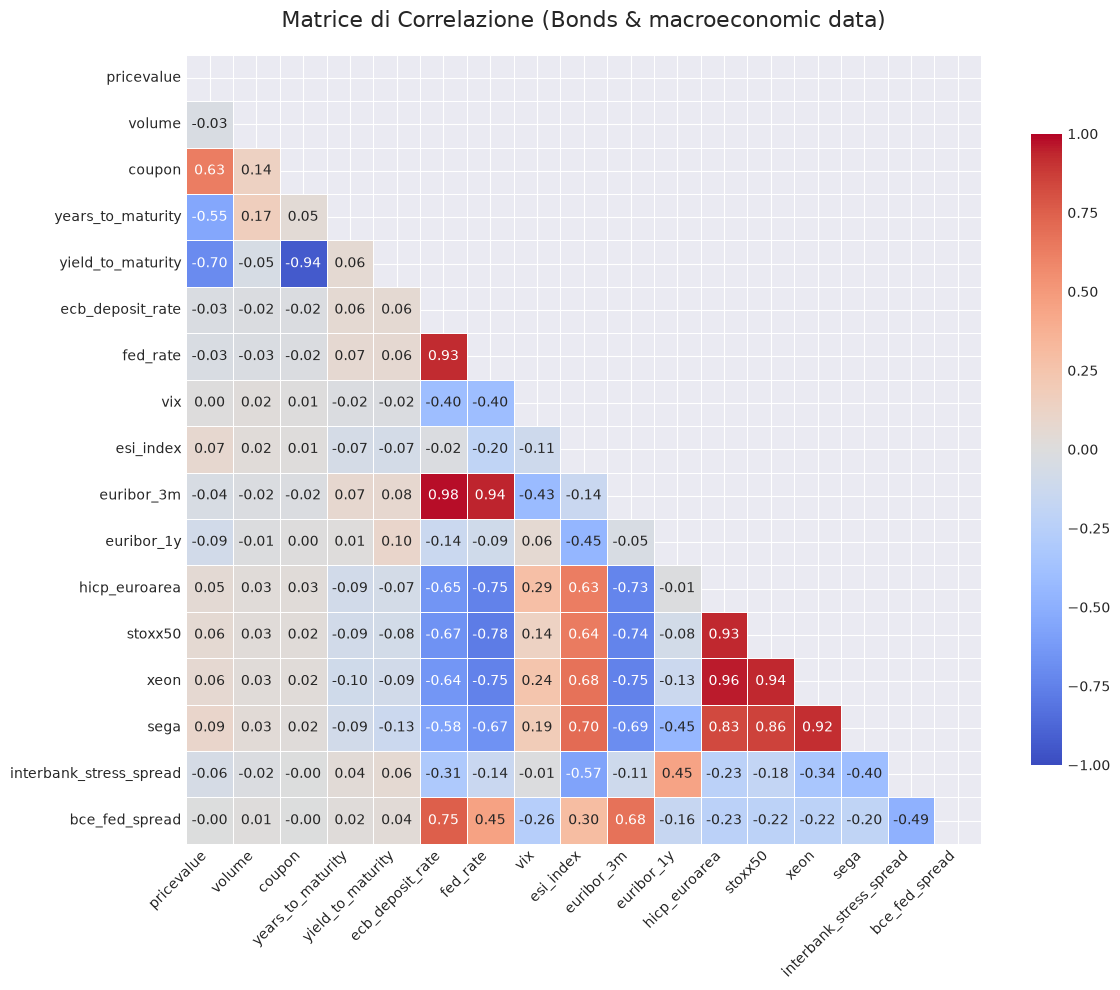

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Selezioniamo solo un sottoinsieme delle features rilevanti
selected_features = [
       'pricevalue', 'volume', 'coupon',
       'years_to_maturity', 'yield_to_maturity','ecb_deposit_rate',
       'fed_rate', 'vix', 'esi_index','euribor_3m', 'euribor_1y',
       'hicp_euroarea', 'stoxx50', 'xeon', 'sega','interbank_stress_spread',
       'short_yield_curve_slope', 'bce_fed_spread'
]

# Assicuriamoci che le colonne selezionate siano presenti nel DataFrame
selected_features = [col for col in selected_features if col in df_bond_macro.columns]

# Calcoliamo la matrice di correlazione
correlation_matrix = df_bond_macro[selected_features].corr()

# Creiamo una maschera per nascondere il triangolo superiore
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Impostiamo le dimensioni della figura
plt.figure(figsize=(12, 10))

# Creiamo la heatmap
sns.heatmap(correlation_matrix, 
            mask=mask, 
            annot=True,          # Mostra i numeri
            fmt=".2f",           # Arrotonda a 2 decimali
            cmap='coolwarm',     # Colori: Rosso per correlazione +, Blu per -
            vmin=-1, vmax=1,     # Scala fissa da -1 a 1
            linewidths=0.5, 
            cbar_kws={"shrink": .8})


plt.title('Matrice di Correlazione (Bonds & macroeconomic data)', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

#plt.savefig('./paper/plots/correlation_matrix_bonds_macro.png', dpi=300, bbox_inches='tight')

plt.show()

E' presente un'altissima correlazione tra ecb_deposit_rate e l'euribor a 3 mesi, decidiamo di scartarlo visto e considerato che l'Euribor è scambiato dalle banche ogni giorno, mentre la BCE cambia i tassi a "gradini" ogni 6 settimane. L'Euribor di conseguenza è molto più reattivo e non dovrebbe confondere i modelli con troppa staticità.

In [84]:
df_bond_macro.drop(columns=['ecb_deposit_rate'], inplace=True)
df_macro_long.drop(columns=['ECB_Deposit_Rate'], inplace=True)

# Salviamo i dataset per i notebook successivi 
df_macro_long.to_csv('./data/df_macro_long.csv')
df_bond_macro.to_csv('./data/df_bond_macro.csv', index=False)

## 2.7 - Lagged Features per dataset Macro only

In questa fase si è deciso di creare delle *Lagged features* per fornire una memoria storica ai modelli tabulari. Essendo il dataset Macro-Only esteso su un orizzonte di 26 anni, i cicli economici (es. inflazione, tassi di interesse) si sviluppano su archi temporali lunghi. Per questo motivo, sono stati generati **lag profondi**: 7, 30, 60, 90 e 120 giorni (coprendo circa un semestre di calendario lavorativo). 

In [85]:
if df_macro_long is not None:
    lags = [7, 30, 60, 90, 120]
    for col in df_macro_long.columns:
        for lag in lags:
            df_macro_long[f'{col}_lag_{lag}d'] = df_macro_long[col].shift(lag)

df_macro_long.dropna(inplace=True)
display(df_macro_long.head())
df_macro_long.to_csv('./data/df_macro_long_lagged.csv')

,FED_Rate,VIX,ESI_Index,Euribor_3M,Euribor_1Y,HICP_Euroarea,interbank_stress_spread,bce_fed_spread,FED_Rate_lag_7d,FED_Rate_lag_30d,...,interbank_stress_spread_lag_7d,interbank_stress_spread_lag_30d,interbank_stress_spread_lag_60d,interbank_stress_spread_lag_90d,interbank_stress_spread_lag_120d,bce_fed_spread_lag_7d,bce_fed_spread_lag_30d,bce_fed_spread_lag_60d,bce_fed_spread_lag_90d,bce_fed_spread_lag_120d
2000-04-30,7.03,26.20,-0.9,3.925278,5.413799,58.7,1.175278,-4.28,7.03,7.03,...,1.425278,1.247043,1.497043,1.343143,1.343143,-4.53,-4.53,-4.78,-5.03,-5.03
2000-05-01,7.03,25.88,-0.5,4.362045,5.515497,58.9,1.612045,-4.28,7.03,7.03,...,1.425278,1.425278,1.497043,1.536762,1.343143,-4.53,-4.53,-4.78,-5.03,-5.03
2000-05-02,7.03,28.50,-0.5,4.362045,5.515497,58.9,1.612045,-4.28,7.03,7.03,...,1.425278,1.425278,1.497043,1.536762,1.343143,-4.53,-4.53,-4.78,-5.03,-5.03
2000-05-03,7.03,31.63,-0.5,4.362045,5.515497,58.9,1.612045,-4.28,7.03,7.03,...,1.425278,1.425278,1.497043,1.536762,1.343143,-4.53,-4.53,-4.78,-5.03,-5.03
2000-05-04,7.03,30.77,-0.5,4.362045,5.515497,58.9,1.612045,-4.28,7.03,7.03,...,1.425278,1.425278,1.497043,1.286762,1.343143,-4.53,-4.53,-4.78,-4.78,-5.03


## 2.8 - Lagged Features per dataset Macro + Bonds

Per il dataset combinato (Macro + Bonds), l'orizzonte temporale è più breve (2023-2026) e la natura del mercato obbligazionario richiede un'analisi tattica e reattiva. Di conseguenza, sono stati scelti **lag di breve/medio termine**: 7, 15 e 30 giorni.

In [86]:
display(df_bond_macro.columns)

Index(['isincode', 'marketcode', 'referencedate', 'pricetype', 'pricevalue',
       'volume', 'mintoday', 'maxtoday', 'description', 'redemptiondate',
       'coupon', 'years_to_maturity', 'yield_to_maturity', 'fed_rate', 'vix',
       'esi_index', 'euribor_3m', 'euribor_1y', 'hicp_euroarea', 'stoxx50',
       'xeon', 'sega', 'interbank_stress_spread', 'bce_fed_spread'],
      dtype='object')

In [87]:
# Applica per ogni ISIN
df_bond_macro = df_bond_macro.sort_values(['isincode', 'referencedate']).reset_index(drop=True)

# Per ogni ISIN, crea lagged features per catturare la memoria storica 
    # Ad es: prezzo di 7 giorni fa, 15 giorni fa, 30 giorni fa
lags = [7, 15, 30]

for lag in lags:
    # Usando groupby().shift() pandas non usa cicli lenti, lo fa a livello C/Cython!
    df_bond_macro[f'pricevalue_lag_{lag}d'] = df_bond_macro.groupby('isincode')['pricevalue'].shift(lag)

# Creiamo lag di 7,15,30 giorni anche per le macro variabili fondamentali in modo da catturare l'effetto ritardato delle condizioni macroeconomiche sui prezzi dei bond
macro_to_lag = ['volume', 'fed_rate',
       'vix', 'esi_index', 'euribor_3m', 'euribor_1y', 'hicp_euroarea',
       'stoxx50', 'xeon', 'sega', 'interbank_stress_spread',
       'short_yield_curve_slope', 'bce_fed_spread',]
for col in macro_to_lag:
    if col in df_bond_macro.columns:
        df_bond_macro[f'{col}_lag_7d'] = df_bond_macro.groupby('isincode')[col].shift(7)
        df_bond_macro[f'{col}_lag_15d'] = df_bond_macro.groupby('isincode')[col].shift(15)
        df_bond_macro[f'{col}_lag_30d'] = df_bond_macro.groupby('isincode')[col].shift(30)

# Scarta le righe con NaN nei lag (i primi 60 giorni per ogni ISIN)
lag_cols = [f'pricevalue_lag_{lag}d' for lag in lags]
df_bond_macro = df_bond_macro.dropna(subset=lag_cols).copy()

print(f"✓ Lagged features creati")
print(f"Dataset dopo lagged features: {df_bond_macro.shape}")
print(f"\nColonne lag:")
lag_cols = [col for col in df_bond_macro.columns if 'lag' in col]
print(lag_cols)

df_bond_macro.to_csv('./data/df_bond_macro_lagged.csv', index=False)

✓ Lagged features creati
Dataset dopo lagged features: (301030, 63)

Colonne lag:
['pricevalue_lag_7d', 'pricevalue_lag_15d', 'pricevalue_lag_30d', 'volume_lag_7d', 'volume_lag_15d', 'volume_lag_30d', 'fed_rate_lag_7d', 'fed_rate_lag_15d', 'fed_rate_lag_30d', 'vix_lag_7d', 'vix_lag_15d', 'vix_lag_30d', 'esi_index_lag_7d', 'esi_index_lag_15d', 'esi_index_lag_30d', 'euribor_3m_lag_7d', 'euribor_3m_lag_15d', 'euribor_3m_lag_30d', 'euribor_1y_lag_7d', 'euribor_1y_lag_15d', 'euribor_1y_lag_30d', 'hicp_euroarea_lag_7d', 'hicp_euroarea_lag_15d', 'hicp_euroarea_lag_30d', 'stoxx50_lag_7d', 'stoxx50_lag_15d', 'stoxx50_lag_30d', 'xeon_lag_7d', 'xeon_lag_15d', 'xeon_lag_30d', 'sega_lag_7d', 'sega_lag_15d', 'sega_lag_30d', 'interbank_stress_spread_lag_7d', 'interbank_stress_spread_lag_15d', 'interbank_stress_spread_lag_30d', 'bce_fed_spread_lag_7d', 'bce_fed_spread_lag_15d', 'bce_fed_spread_lag_30d']


In [88]:
# Controlliamo quanti NaN abbiamo dopo aver creato i lag
print(f"  Numero di NaN dopo lag: {df_bond_macro.isnull().sum().sum()}")

# quale colonna ha più NaN?
nan_counts = df_bond_macro.isnull().sum()
nan_counts = nan_counts[nan_counts > 0].sort_values(ascending=False)
print("\nColonne con NaN dopo lag (ordinato):")
print(nan_counts)

  Numero di NaN dopo lag: 0

Colonne con NaN dopo lag (ordinato):
Series([], dtype: int64)


## 2.9 - Analisi Preprocessed Data for Modeling

Abbiamo quindi ottenuto due data lake distinti:

1. **Dataset Macro-Bond (Tattico):** 301030 osservazioni arricchite con lag a 30 giorni e indicatori di rischio interbancario. È il dataset *Core* su cui addestreremo i modelli a prevedere il miglior *entry-point* per i singoli titoli.
2. **Dataset Macro-Only (Strategico):** 9505 osservazioni giornaliere (26 anni di storia) con lag fino a 120 giorni. Sarà utilizzato per testare la capacità dei modelli di prevedere i *Regime Shifts* macroeconomici di lungo periodo.

I dati sono ora pronti per essere passati al modulo di Modeling e Validazione (Notebook 03), dove verranno isolati tramite *Purged Time-Series Split* per garantire l'assoluta assenza di Lookahead Bias durante l'addestramento.

In [89]:
# MACRO + BONDS LAGGED
print(f"\nRiepilogo Dataset Macro-Bond:")
print(f"  Numero di righe: {df_bond_macro.shape[0]}")
print(f"  Numero di colonne: {df_bond_macro.shape[1]}")
print(f"  Numero di ISIN unici: {df_bond_macro['isincode'].nunique()}")
print(f"  Numero di NaN dopo lag: {df_bond_macro.isnull().sum().sum()}")
print(f"  Data range: {df_bond_macro['referencedate'].min()} - {df_bond_macro['referencedate'].max()}")
print(f"\nFeatures:")
for col in df_bond_macro.columns:
    if col != 'isincode' and col != 'referencedate':
        print(f"  - {col}")


Riepilogo Dataset Macro-Bond:
  Numero di righe: 301030
  Numero di colonne: 63
  Numero di ISIN unici: 462
  Numero di NaN dopo lag: 0
  Data range: 2023-02-15 00:00:00 - 2026-05-07 00:00:00

Features:
  - marketcode
  - pricetype
  - pricevalue
  - volume
  - mintoday
  - maxtoday
  - description
  - redemptiondate
  - coupon
  - years_to_maturity
  - yield_to_maturity
  - fed_rate
  - vix
  - esi_index
  - euribor_3m
  - euribor_1y
  - hicp_euroarea
  - stoxx50
  - xeon
  - sega
  - interbank_stress_spread
  - bce_fed_spread
  - pricevalue_lag_7d
  - pricevalue_lag_15d
  - pricevalue_lag_30d
  - volume_lag_7d
  - volume_lag_15d
  - volume_lag_30d
  - fed_rate_lag_7d
  - fed_rate_lag_15d
  - fed_rate_lag_30d
  - vix_lag_7d
  - vix_lag_15d
  - vix_lag_30d
  - esi_index_lag_7d
  - esi_index_lag_15d
  - esi_index_lag_30d
  - euribor_3m_lag_7d
  - euribor_3m_lag_15d
  - euribor_3m_lag_30d
  - euribor_1y_lag_7d
  - euribor_1y_lag_15d
  - euribor_1y_lag_30d
  - hicp_euroarea_lag_7d
  - hi

In [90]:
# MACRO ONLY LAGGED
print(f"\nRiepilogo Dataset Macro-Only:")
print(f"  Numero di righe: {df_macro_long.shape[0]}")
print(f"  Numero di colonne: {df_macro_long.shape[1]}")
print(f"  Numero di NaN dopo lag: {df_macro_long.isnull().sum().sum()}")
print(f"  Data range: {df_macro_long.index.min()} - {df_macro_long.index.max()}")
print(f"\nFeatures:")
for col in df_macro_long.columns:
    if col != 'isincode' and col != 'referencedate':
        print(f"  - {col}")


Riepilogo Dataset Macro-Only:
  Numero di righe: 9505
  Numero di colonne: 48
  Numero di NaN dopo lag: 0
  Data range: 2000-04-30 00:00:00 - 2026-05-08 00:00:00

Features:
  - FED_Rate
  - VIX
  - ESI_Index
  - Euribor_3M
  - Euribor_1Y
  - HICP_Euroarea
  - interbank_stress_spread
  - bce_fed_spread
  - FED_Rate_lag_7d
  - FED_Rate_lag_30d
  - FED_Rate_lag_60d
  - FED_Rate_lag_90d
  - FED_Rate_lag_120d
  - VIX_lag_7d
  - VIX_lag_30d
  - VIX_lag_60d
  - VIX_lag_90d
  - VIX_lag_120d
  - ESI_Index_lag_7d
  - ESI_Index_lag_30d
  - ESI_Index_lag_60d
  - ESI_Index_lag_90d
  - ESI_Index_lag_120d
  - Euribor_3M_lag_7d
  - Euribor_3M_lag_30d
  - Euribor_3M_lag_60d
  - Euribor_3M_lag_90d
  - Euribor_3M_lag_120d
  - Euribor_1Y_lag_7d
  - Euribor_1Y_lag_30d
  - Euribor_1Y_lag_60d
  - Euribor_1Y_lag_90d
  - Euribor_1Y_lag_120d
  - HICP_Euroarea_lag_7d
  - HICP_Euroarea_lag_30d
  - HICP_Euroarea_lag_60d
  - HICP_Euroarea_lag_90d
  - HICP_Euroarea_lag_120d
  - interbank_stress_spread_lag_7d
  - in